In [179]:
import numpy as np
import pandas as pd
from sklearn.feature_selection import mutual_info_regression, mutual_info_classif
from scipy.stats import pearsonr

# --- load ---
df = pd.read_csv("../data/12k_all.csv")
df["abs_final_score"] = df["final_score"].abs()

columns = [
    "B_hs_engaged","C_hs_engaged","all_hs_engaged","iplddt","pae","pde","esm2_log_likelihood",
    "A_B_ipSAE","A_B_ipSAE_max","A_C_ipSAE","A_C_ipSAE_max","A_B_ipSAE_d0chn","A_B_ipSAE_d0chn_max",
    "A_C_ipSAE_d0chn","A_C_ipSAE_d0chn_max","A_B_ipSAE_d0dom","A_B_ipSAE_d0dom_max","A_C_ipSAE_d0dom",
    "A_C_ipSAE_d0dom_max","A_BC_iptm","A_B_iptm","A_C_iptm","total_score","A_BC_complex_normalized",
    "A_BC_dG_cross","A_BC_dG_cross/dSASAx100","A_BC_dG_separated","A_BC_dG_separated/dSASAx100",
    "A_BC_dSASA_hphobic","A_BC_dSASA_int","A_BC_dSASA_polar","A_BC_delta_unsatHbonds","A_BC_hbond_E_fraction",
    "A_BC_hbonds_int","A_BC_nres_all","A_BC_nres_int","A_BC_packstat","A_BC_per_residue_energy_int",
    "A_BC_sc_value","A_BC_side1_normalized","A_BC_side1_score","A_BC_side2_normalized","A_BC_side2_score",
    "A_B_complex_normalized","A_B_dG_cross","A_B_dG_cross/dSASAx100","A_B_dG_separated","A_B_dG_separated/dSASAx100",
    "A_B_dSASA_hphobic","A_B_dSASA_int","A_B_dSASA_polar","A_B_delta_unsatHbonds","A_B_hbond_E_fraction",
    "A_B_hbonds_int","A_B_nres_all","A_B_nres_int","A_B_packstat","A_B_per_residue_energy_int","A_B_sc_value",
    "A_B_side1_normalized","A_B_side1_score","A_B_side2_normalized","A_B_side2_score","A_C_complex_normalized",
    "A_C_dG_cross","A_C_dG_cross/dSASAx100","A_C_dG_separated","A_C_dG_separated/dSASAx100","A_C_dSASA_hphobic",
    "A_C_dSASA_int","A_C_dSASA_polar","A_C_delta_unsatHbonds","A_C_hbond_E_fraction","A_C_hbonds_int","A_C_nres_all",
    "A_C_nres_int","A_C_packstat","A_C_per_residue_energy_int","A_C_sc_value","A_C_side1_normalized","A_C_side1_score",
    "A_C_side2_normalized","A_C_side2_score","complex_normalized","dG_cross","dG_cross/dSASAx100","dG_separated",
    "dG_separated/dSASAx100","dSASA_hphobic","dSASA_int","dSASA_polar","delta_unsatHbonds","hbond_E_fraction",
    "hbonds_int","nres_all","nres_int","packstat","per_residue_energy_int","sc_value","side1_normalized","side1_score",
    "side2_normalized","side2_score","logFC","logCPM","LR","PValue","FDR","2-fold threshold?","Significant",
    "final_score","abs_final_score",#"custom_score"
]
exclude = ["logFC","logCPM","LR","PValue","FDR","2-fold threshold?","Significant","final_score","abs_final_score"]

df["2-fold threshold?"] = df["2-fold threshold?"].fillna("Not Sig")
df = df.fillna(0)
df["Significant"] = df["Significant"].astype(int)
df["esm2_log_likelihood_norm"] = (df["esm2_log_likelihood"] - df["esm2_log_likelihood"].min()) / (df["esm2_log_likelihood"].max() - df["esm2_log_likelihood"].min())
df["complex_normalized_norm"] = (df["complex_normalized"] - df["complex_normalized"].min()) / (df["complex_normalized"].max() - df["complex_normalized"].min())
df["iplddt_norm"] = (df["A_B_hbonds_int"] - df["A_B_hbonds_int"].min()) / (df["A_B_hbonds_int"].max() - df["A_B_hbonds_int"].min())
df["custom_score"] = df["esm2_log_likelihood_norm"] - df["complex_normalized_norm"]# - df["pae"]
# df = df[df["Significant"] == 1]

# col that adds minmax normalized complex_normalized with negative esm2_log_likelihood. first make norm cols

# results = []
# for col in columns:
#     if col in exclude:
#         continue
#     if df[col].nunique() <= 1:
#         continue

#     # Pearson vs final_score
#     pearson_corr_fs, pearson_pval_fs = pearsonr(df[col], df["logFC"])

#     # Mutual information (regression for final_score, classification for Significant)
#     mi_reg = mutual_info_regression(df[[col]], df["logFC"], random_state=0)[0]

#     results.append({
#         "feature": col,
#         "pearson_corr_final": pearson_corr_fs,
#         "pearson_pval_final": pearson_pval_fs,
#         "mi_reg": mi_reg,
#     })

# results_df = pd.DataFrame(results).sort_values(by="pearson_corr_final", key=abs, ascending=False)
# results_df

# scatter plot w/ pearson r for esm2, complex_normalized, custom_score vs logFC. 3 separate plots
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns

# order = ["Up", "Not Sig", "Down"]
# palette = {"Up": "C2", "Down": "C3", "Not Sig": "C0"}

# for feature in ["esm2_log_likelihood", "complex_normalized", "custom_score", "iplddt", "pae"]:
#     plt.rcParams.update({'font.size': 12})
#     fig, ax = plt.subplots(figsize=(6,4))

#     # ordered categorical for y
#     df["twofold_cat"] = pd.Categorical(
#         df["2-fold threshold?"],
#         categories=order,
#         ordered=True
#     )

#     sns.violinplot(
#         data=df,
#         x=feature,
#         y="twofold_cat",
#         orient="h",
#         order=order,
#         palette=palette,
#         # hue="twofold_cat",
#         ax=ax,
#         cut=0,
        
#     )

#     # counts for rows actually used in the plot (drop NaNs in feature)
#     valid = df["twofold_cat"].notna() & df[feature].notna()
#     counts = (df.loc[valid, "twofold_cat"]
#                 .value_counts()
#                 .reindex(order)
#                 .fillna(0)
#                 .astype(int))

#     ax.set_yticks(range(len(order)))
#     ax.set_yticklabels([f"{lab} (n={counts[lab]})" for lab in order])
#     new_labels = []
#     for lab in order:
#         if lab == "Not Sig":
#             new_labels += [f"{lab} (n={counts[lab]})"]
#         else:
#             new_labels += [f"{lab} ≥2-Fold (n={counts[lab]})"]
#     ax.set_yticklabels(new_labels)

#     # hide y tick marks
#     ax.tick_params(axis='y', length=0)
#     ax.set_ylabel("")
            

#     ax.set_xlabel(feature)

#     plt.savefig(f"../results/feature_{feature}_by_2foldcat.png", dpi=300, bbox_inches='tight')

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Up vs. Not Sig: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:5.086e-23 U_stat=3.054e+06
Not Sig vs. Down: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:9.891e-45 U_stat=1.512e+06
Up vs. Down: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:3.557e-34 U_stat=9.458e+04


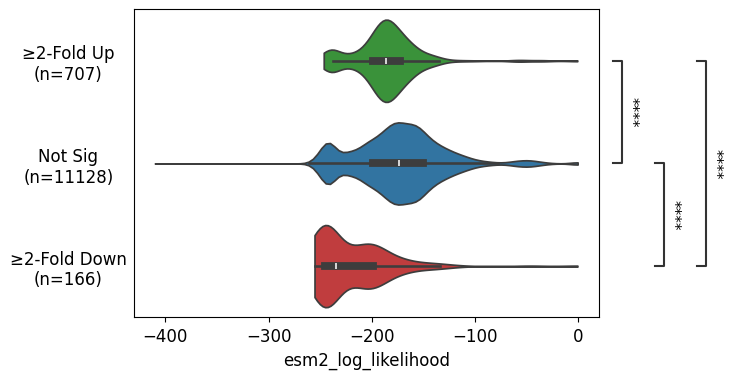

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Up vs. Not Sig: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:3.687e-02 U_stat=4.154e+06
Not Sig vs. Down: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:1.275e-32 U_stat=4.249e+05
Up vs. Down: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:3.168e-28 U_stat=2.627e+04


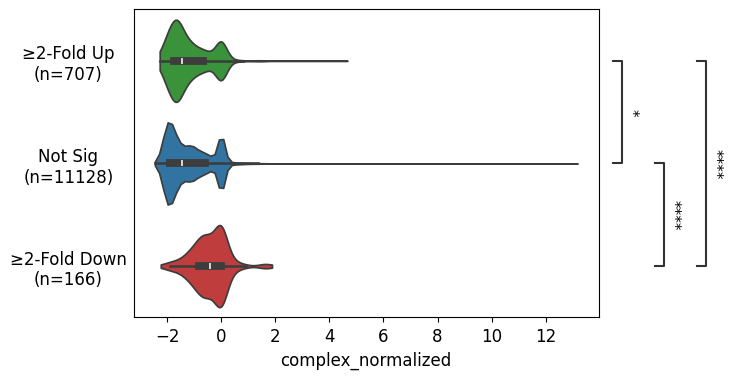

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Up vs. Not Sig: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:5.377e-19 U_stat=3.139e+06
Not Sig vs. Down: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:9.617e-48 U_stat=1.532e+06
Up vs. Down: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:2.854e-41 U_stat=9.826e+04


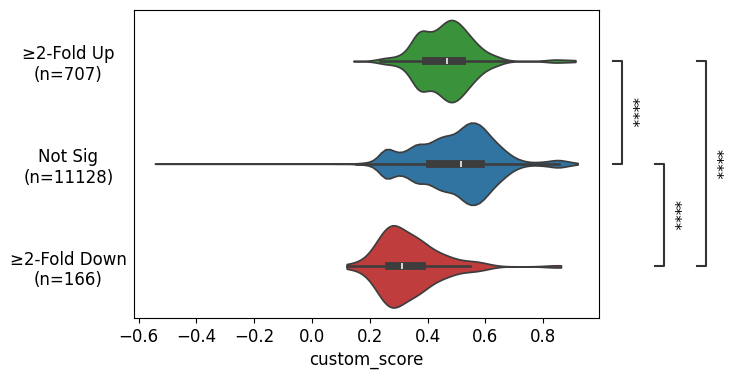

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Up vs. Not Sig: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:7.181e-03 U_stat=3.666e+06
Not Sig vs. Down: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:2.954e-21 U_stat=1.323e+06
Up vs. Down: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:4.841e-17 U_stat=8.355e+04


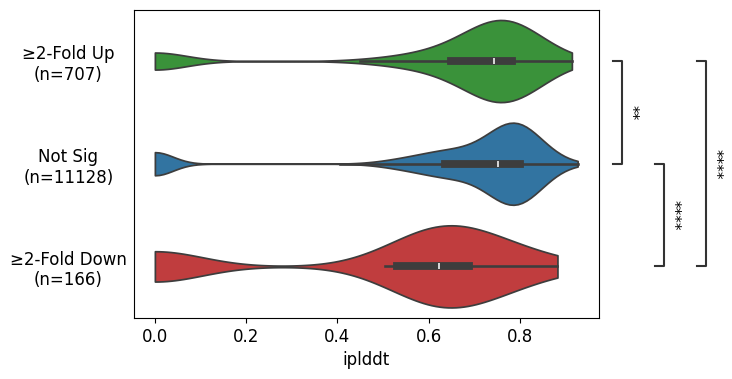

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Up vs. Not Sig: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:1.017e-01 U_stat=4.120e+06
Not Sig vs. Down: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:1.884e-02 U_stat=1.037e+06
Up vs. Down: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:1.993e-03 U_stat=6.862e+04


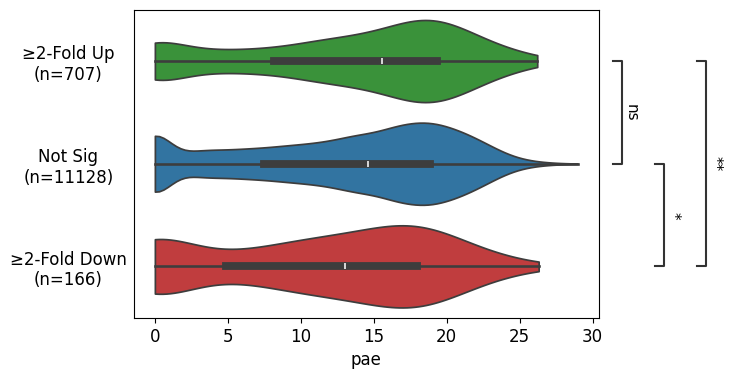

In [ ]:
# pip install statannotations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statannotations.Annotator import Annotator

order = ["Up", "Not Sig", "Down"]
palette = {"Up": "C2", "Down": "C3", "Not Sig": "C0"}
pairs = [("Up", "Not Sig"), ("Down", "Not Sig"), ("Up", "Down")]

# ensure ordered categorical once
df["twofold_cat"] = pd.Categorical(df["2-fold threshold?"], categories=order, ordered=True)

for feature in ["esm2_log_likelihood", "complex_normalized", "custom_score", "iplddt", "pae",]:
    plt.rcParams.update({'font.size': 12})
    fig, ax = plt.subplots(figsize=(6,4))

    sns.violinplot(
        data=df,
        x=feature,
        y="twofold_cat",
        orient="h",
        order=order,
        palette=palette,
        hue="twofold_cat",
        ax=ax,
        cut=0,
        # scale="width"
    )

    # counts based on actually plotted data
    valid = df["twofold_cat"].notna() & df[feature].notna()
    dplot = df.loc[valid]
    counts = (dplot["twofold_cat"].value_counts().reindex(order).fillna(0).astype(int))

    # y tick labels with counts and ≥2-Fold text
    new_labels = []
    for lab in order:
        if lab == "Not Sig":
            new_labels.append(f"{lab}\n(n={counts[lab]})")
        else:
            new_labels.append(f"≥2-Fold {lab}\n(n={counts[lab]})")
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels(new_labels)
    ax.tick_params(axis='y', length=0)
    ax.set_ylabel("")
    ax.set_xlabel(feature)
    # now center the y tick text as it is currently right aligned. make sure it is still far enough left tho
    for label in ax.get_yticklabels():
        label.set_horizontalalignment('center')
        label.set_x(-0.13)  # adjust this value as needed to move left/right
    



    # bracket-style stars with Bonferroni correction
    annotator = Annotator(
        ax,
        pairs,
        data=dplot,
        x=feature,
        y="twofold_cat",
        order=order,
        orient="h"
    )
    annotator.configure(
        test="Mann-Whitney",
        comparisons_correction="bonferroni",
        text_format="star",
        pvalue_thresholds=[(1e-4, "****"), (1e-3, "***"), (1e-2, "**"), (0.05, "*"), (1, "ns")],
        show_test_name=False,
        loc="outside",
        fontsize=11,
        hide_non_significant=False
    )
    annotator.apply_and_annotate()

    plt.savefig(f"../results/feature_{feature}_by_2foldcat.png", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)

In [92]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_regression, mutual_info_classif


df["2-fold threshold?"] = df["2-fold threshold?"].apply(lambda x: 1 if x == "Up" else (0 if x == "Not Sig" else (-1 if x == "Down" else np.nan)))

# --- choose which columns to include ---
measurement_cols = [
    "logFC","logCPM","LR","PValue","FDR",
    "2-fold threshold?","Significant",
    "final_score","abs_final_score"
]

# start from your 'columns' list but drop the measurement cols from the feature pool
feature_cols = [c for c in columns if c in df.columns and c not in measurement_cols]

# drop constant features (exact same value across all rows)
feature_cols = [c for c in feature_cols if df[c].nunique(dropna=False) > 1]

# final order: features first, then measurements (only those present in df)
all_cols = feature_cols + [c for c in measurement_cols if c in df.columns]

# --- prep the 3-class label codes for classification MI ---
if "2-fold threshold?" in df.columns:
    # treat it as categorical; codes: 0..K-1, -1 for NaN (we'll mask those rows)
    y_class_codes = df["2-fold threshold?"].astype("category").cat.codes.values
else:
    y_class_codes = None

def _mi_vs_target(y, y_is_class=False):
    """
    Return a Series of MI for all features in all_cols vs target y.
    For class target, drops rows where y is NaN (code = -1).
    Handles constant y by returning NaNs.
    """
    X = df[all_cols]

    if y_is_class:
        mask = y >= 0  # keep rows with valid class label
        if mask.sum() == 0:
            return pd.Series(np.nan, index=all_cols)
        mi = mutual_info_classif(
            X.loc[mask, all_cols], y[mask],
            random_state=0, n_neighbors=5, discrete_features=False
        )
    else:
        # constant target -> undefined MI
        if pd.Series(y).nunique(dropna=False) <= 1:
            return pd.Series(np.nan, index=all_cols)
        mi = mutual_info_regression(
            X[all_cols], y,
            random_state=0, n_neighbors=5, discrete_features=False
        )
    return pd.Series(mi, index=all_cols)

# --- compute MI for each column as the target ---
mi_cols = []
for col in all_cols:
    if col == "2-fold threshold?":
        mi_series = _mi_vs_target(y_class_codes, y_is_class=True)
    else:
        mi_series = _mi_vs_target(df[col].values, y_is_class=False)
    mi_cols.append(mi_series.rename(col))

mi_matrix = pd.concat(mi_cols, axis=1)

# symmetrize and zero diagonal
mi_matrix = (mi_matrix + mi_matrix.T) / 2.0
np.fill_diagonal(mi_matrix.values, 0.0)

# drop rows/cols that are all-NaN (e.g., constant measurement)
valid = mi_matrix.notna().any(axis=1)
mi_matrix = mi_matrix.loc[valid, valid]

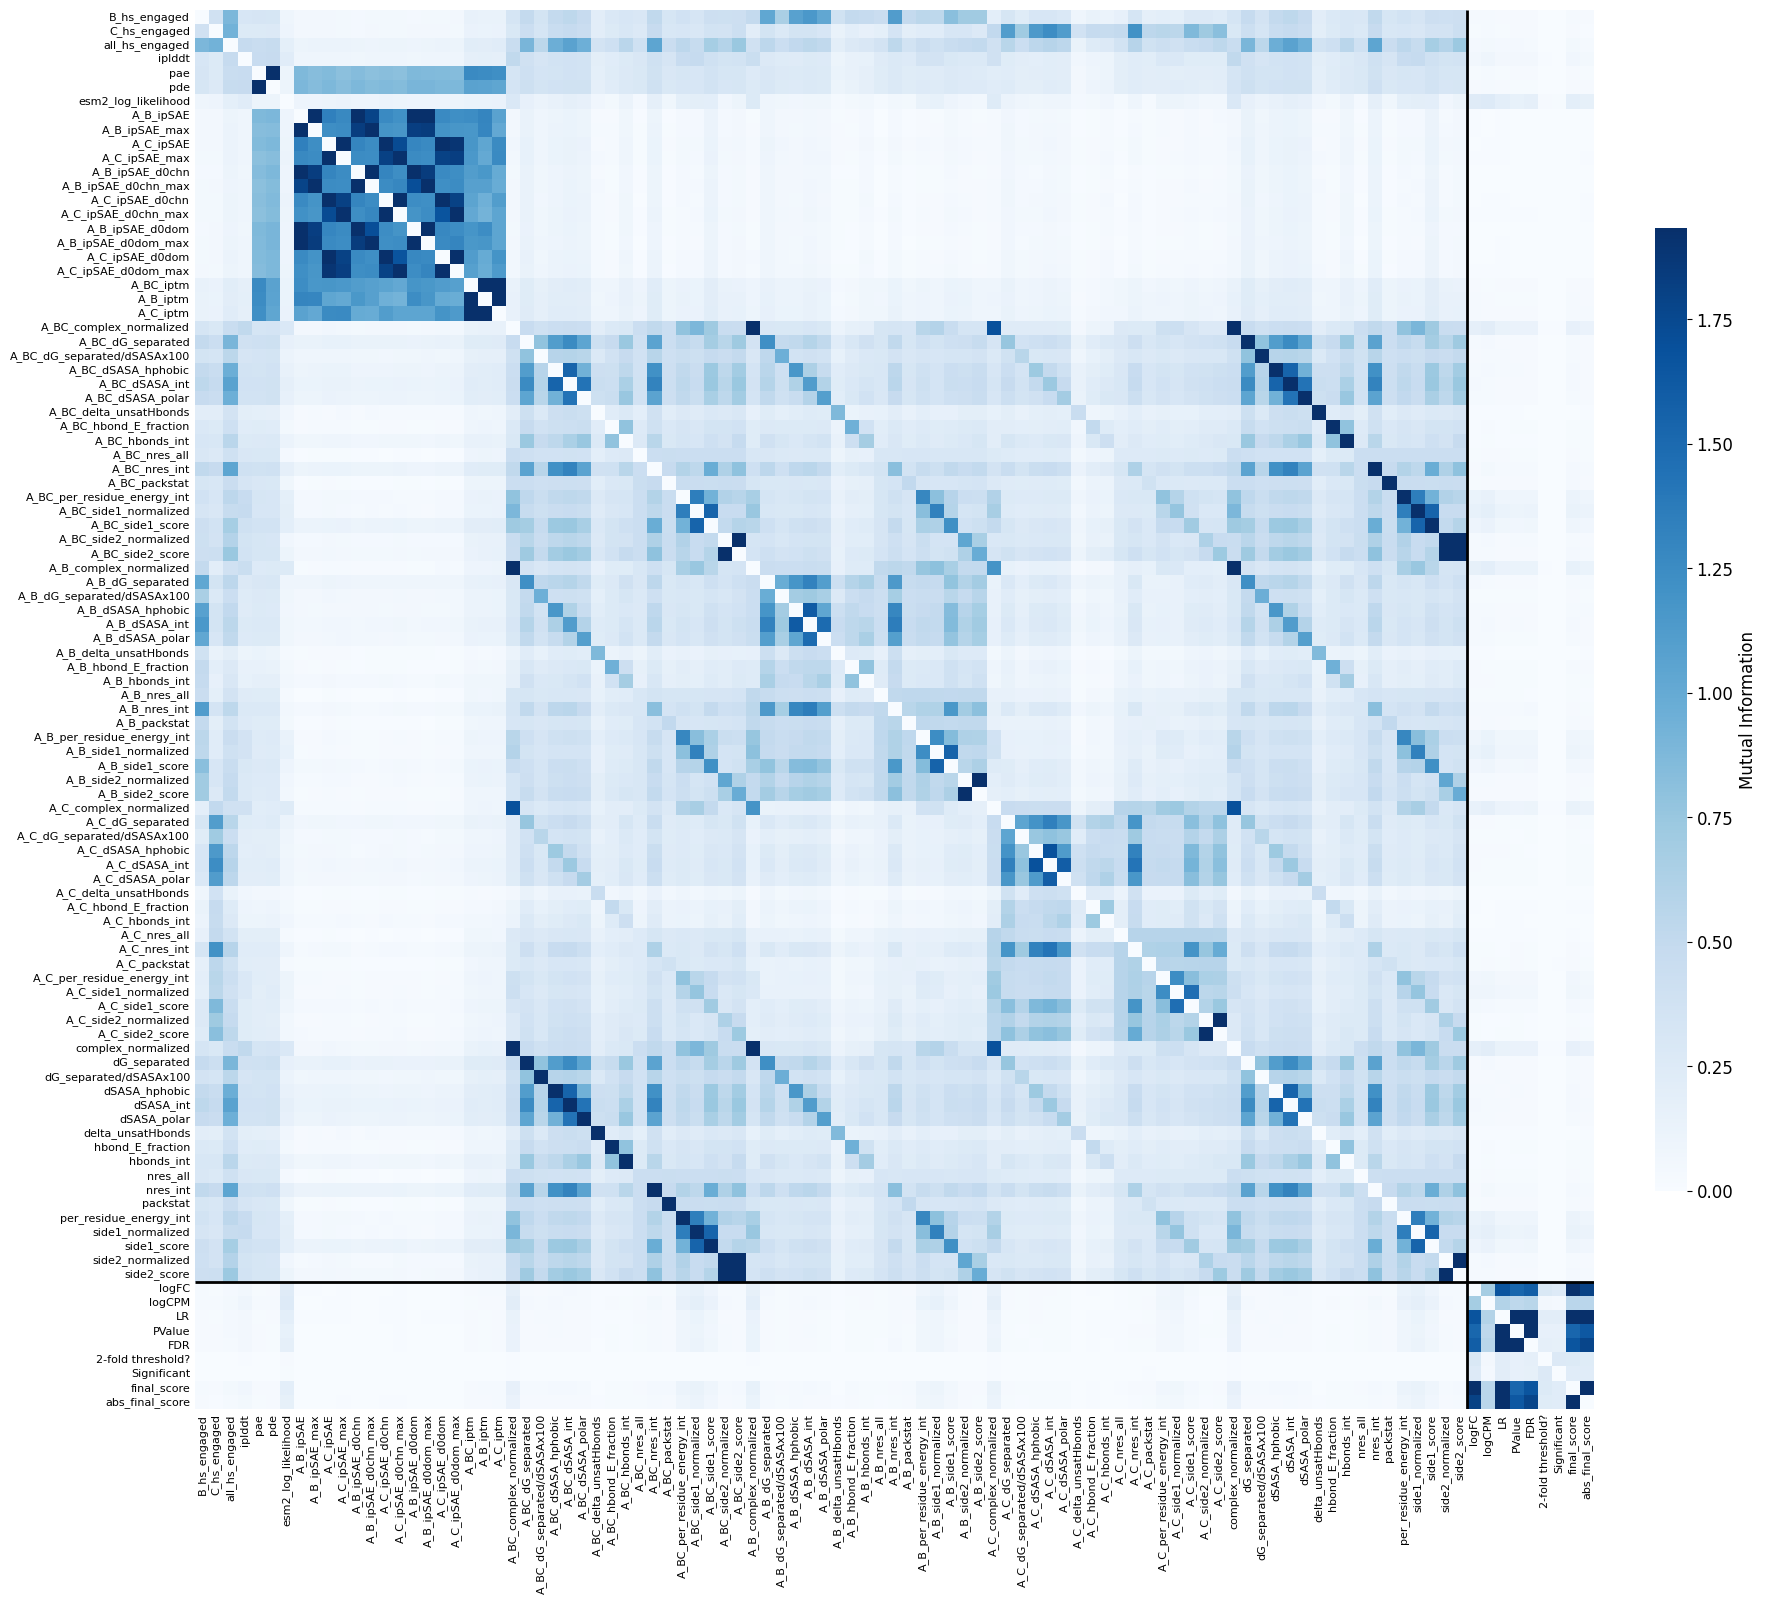

In [155]:
# --- plot heatmap ---
n = mi_matrix.shape[0]
fig_w = max(10, n * 0.18)
fig_h = max(10, n * 0.18)
fig, ax = plt.subplots(figsize=(fig_w, fig_h))

# cap color scale to reduce outlier dominance
vmax = np.nanquantile(mi_matrix.values[np.isfinite(mi_matrix.values)], 0.99)

sns.heatmap(
    mi_matrix, cmap="Blues", vmin=0, vmax=vmax, square=True,
    cbar_kws={
        "label": "Mutual Information",
        "shrink": 0.6,     # shorter
        "fraction": 0.03,  # thinner
        "pad": 0.04,       # closer to the plot
        "aspect": 30       # shape ratio
    },
    xticklabels=True, yticklabels=True, ax=ax,
    # linecolor="white", linewidth=0.01
)

# draw separators before the measurement block
k = len([c for c in feature_cols if c in mi_matrix.index])
if 0 < k < n:
    ax.vlines(k, 0, n, colors="black", lw=2)
    ax.hlines(k, 0, n, colors="black", lw=2)

# color tick labels for the three measurements to make them obvious
meas_set = set([c for c in measurement_cols if c in mi_matrix.columns])

# make x and y tick labels smaller font size
for lbl in ax.get_xticklabels():
    lbl.set_fontsize(8)
# make x and y tick labels smaller font size
for lbl in ax.get_yticklabels():
    lbl.set_fontsize(8)

# hide x and y tick marks
ax.tick_params(axis='x', length=0)
ax.tick_params(axis='y', length=0)

plt.tight_layout()
plt.savefig("../results/mi_heatmap_all_features.png", dpi=300, bbox_inches="tight")